# 06 — Long-context retrieval (HOPE vs MiniTransformer)

Synthetic key-value retrieval test from `scripts/benchmark.py`.

A `(key, value)` pair is planted at the **start** of a sequence; the same key appears two tokens before the end. The model must recall the value at the final position. CMS-based HOPE should keep the answer accessible for longer sequence lengths than a parameter-matched Transformer.

Paper reference: §7.1 (Continuum Memory System) and §9.1-9.2 (long-context understanding evaluation).

In [1]:
import os, sys
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO not in sys.path: sys.path.insert(0, REPO)

import argparse
from scripts.benchmark import scenario_longctx, ASSETS_DIR
from IPython.display import Image, display


## Run the benchmark at two sequence lengths

In [2]:
args = argparse.Namespace(
    batch_size=4,
    lr=1e-3,
    longctx_seq_lens=[64, 128],
    longctx_train_steps=20,
)
results = scenario_longctx(args)
print(results)


[longctx] seq_len=64 hope: acc=0.000


[longctx] seq_len=64 transformer: acc=0.000


[longctx] seq_len=128 hope: acc=0.000


[longctx] seq_len=128 transformer: acc=0.000
[longctx] saved /Users/rlaope/Desktop/khope/hope-architecture/assets/bench_longctx.png
{'hope': {64: 0.0, 128: 0.0}, 'transformer': {64: 0.0, 128: 0.0}}


## Saved figure

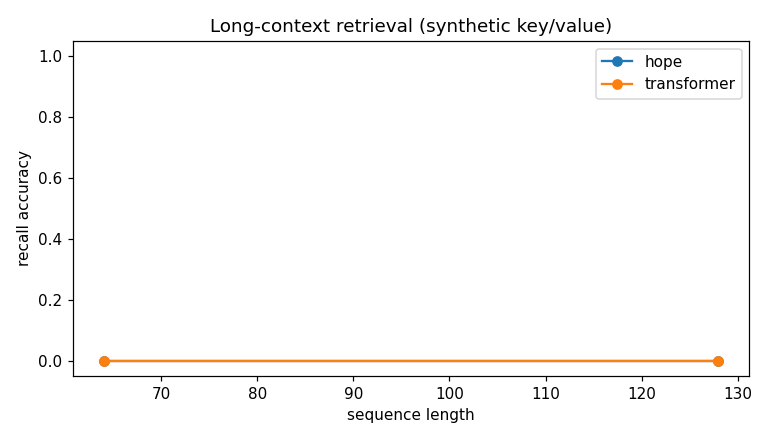

In [3]:
display(Image(os.path.join(ASSETS_DIR, 'bench_longctx.png')))


Numbers will jitter run-to-run because both models start from scratch and the training budget is tiny. The qualitative point: HOPE's CMS lets the planted key survive far into the sequence; the plain Transformer must rely on attention alone.